In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv(r"C:\Users\Divya\Downloads\colorado_motor_vehicle_sales.csv")
df

,year,quarter,county,sales
0,2008,1,Adams,231609000
1,2008,1,Arapahoe,550378000
2,2008,1,Boulder/Broomfield,176771000
3,2008,1,Denver,200103000
4,2008,1,Douglas,93259000
...,...,...,...,...
496,2015,4,Larimer,244327000
497,2015,4,Mesa,88202000
498,2015,4,Pueblo,94606000
499,2015,4,Rest of State,157059000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   year     501 non-null    int64 
 1   quarter  501 non-null    int64 
 2   county   501 non-null    object
 3   sales    501 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [4]:
df.describe()

,year,quarter,sales
count,501.000000,501.000000,5.010000e+02
mean,2011.570858,2.502994,1.760585e+08
std,2.266599,1.120041,1.642055e+08
min,2008.000000,1.000000,6.274000e+06
25%,2010.000000,2.000000,6.148200e+07
50%,2012.000000,3.000000,1.385820e+08
75%,2014.000000,4.000000,2.241580e+08
max,2015.000000,4.000000,9.169100e+08


In [5]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
496    False
497    False
498    False
499    False
500    False
Length: 501, dtype: bool

In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

year       0
quarter    0
county     0
sales      0
dtype: int64

In [8]:
df.columns

Index(['year', 'quarter', 'county', 'sales'], dtype='object')

In [11]:
df['month'] = df['quarter'].apply(lambda x: {1: 1, 2: 4, 3: 7, 4: 10}[x])

In [12]:
df['date'] = pd.to_datetime(df[['year', 'month']].assign(DAY=1))

In [13]:
df.set_index('date', inplace=True)


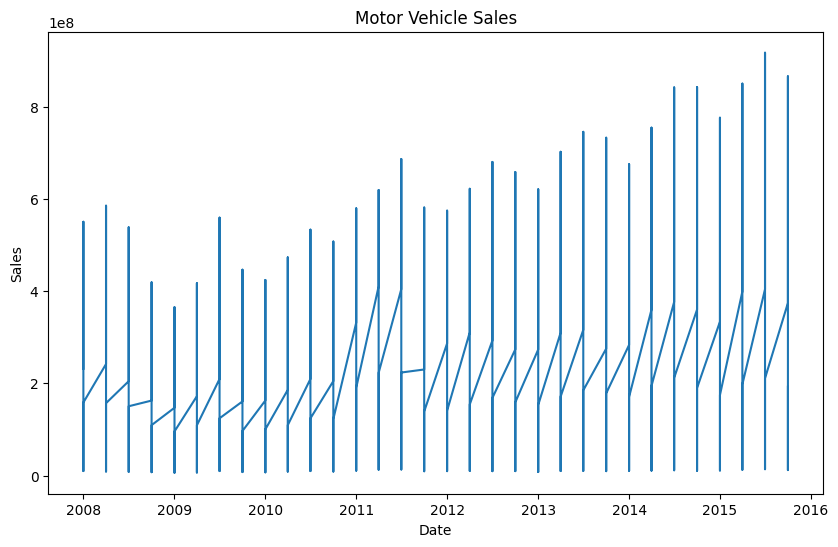

In [14]:
plt.figure(figsize=(10,6))
plt.plot(df['sales'])
plt.title('Motor Vehicle Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [15]:
from statsmodels.tsa.arima.model import ARIMA

In [17]:
model = ARIMA(df['sales'], order=(1,1,1))
model_fit = model.fit()

C:\Users\Divya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Divya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Divya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [18]:
model_fit = model.fit()

In [19]:
forecast = model_fit.forecast(steps=30)

C:\Users\Divya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Divya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [20]:
forecast

501    2.115339e+08
502    2.118616e+08
503    2.118672e+08
504    2.118673e+08
505    2.118673e+08
506    2.118673e+08
507    2.118673e+08
508    2.118673e+08
509    2.118673e+08
510    2.118673e+08
511    2.118673e+08
512    2.118673e+08
513    2.118673e+08
514    2.118673e+08
515    2.118673e+08
516    2.118673e+08
517    2.118673e+08
518    2.118673e+08
519    2.118673e+08
520    2.118673e+08
521    2.118673e+08
522    2.118673e+08
523    2.118673e+08
524    2.118673e+08
525    2.118673e+08
526    2.118673e+08
527    2.118673e+08
528    2.118673e+08
529    2.118673e+08
530    2.118673e+08
Name: predicted_mean, dtype: float64

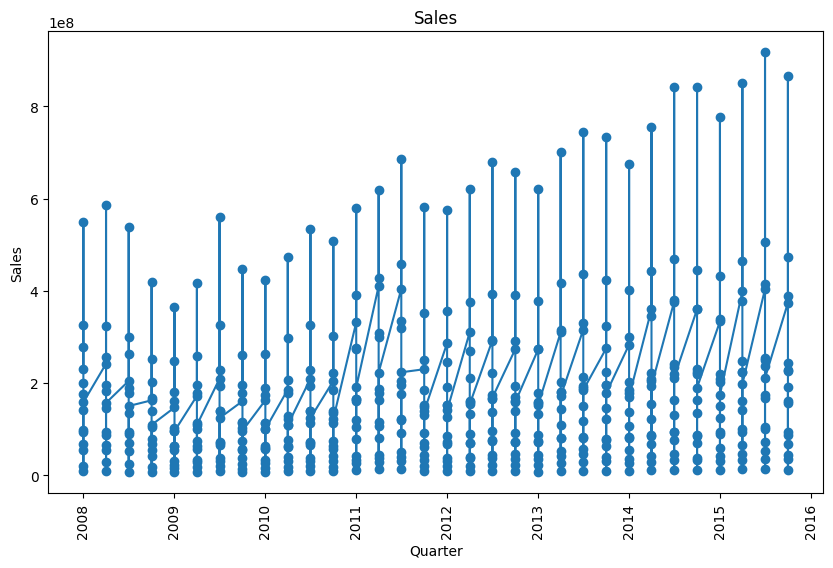

In [21]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["sales"], marker='o')
plt.title("Sales")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()


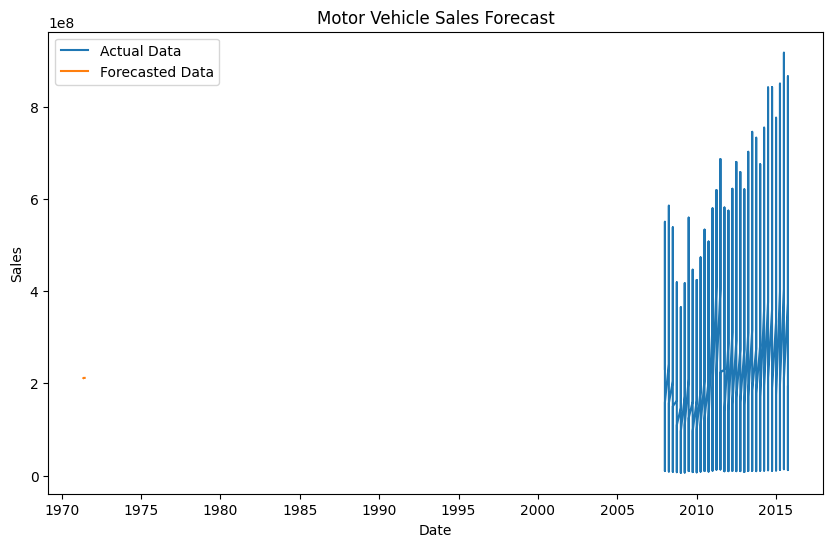

In [23]:
plt.figure(figsize=(10,6))
plt.plot(df['sales'], label='Actual Data')
plt.plot([None for i in df['sales']] + [x for x in forecast], label='Forecasted Data')
plt.title('Motor Vehicle Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()